In [ ]:
44. How do orders change by year?
45. How do orders change by month?
46. Which month has the highest number of orders?
47. Which month has the highest revenue?
48. Is there seasonal behavior?
### Visualization
Line chart:
sns.lineplot(...)


In [ ]:
For every question, follow this pattern:


Business Question
       ↓
What data do I need?
       ↓
Which tables?
       ↓
Do I need merge?
       ↓
Do I need cleaning?
       ↓
Which Pandas function?
       ↓
Calculate
       ↓
Visualize
       ↓
Interpret
       ↓
Business insight


In [14]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
folder_path = "C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data"
data = {}
for file in os.listdir(folder_path):
    # print(file.split(".")[0])
    data[file.split(".")[0].replace("olist_","").replace("_dataset","").replace("order_","")] = folder_path + "/" + file
data
    

{'customers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_customers_dataset.csv',
 'geolocation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_geolocation_dataset.csv',
 'orders': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_orders_dataset.csv',
 'items': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_items_dataset.csv',
 'payments': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_payments_dataset.csv',
 'reviews': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_reviews_dataset.csv',
 'products': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_products_dataset.csv',
 'sellers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_sellers_dataset.csv',
 'product_category_name_translation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/product_category_name_transla

In [ ]:
44. How do orders change by year?
in orders table we have order_purchase_timestamp.first i converted from object to datetime using pd.to_datetime().
then extracted the year using .dt.year.
grouped the orders by year column and then count the number of orders using order_id.then visualized yearly orders using sns chart.
     [2016, 2017, 2018] ----------> [329, 45101, 54011]

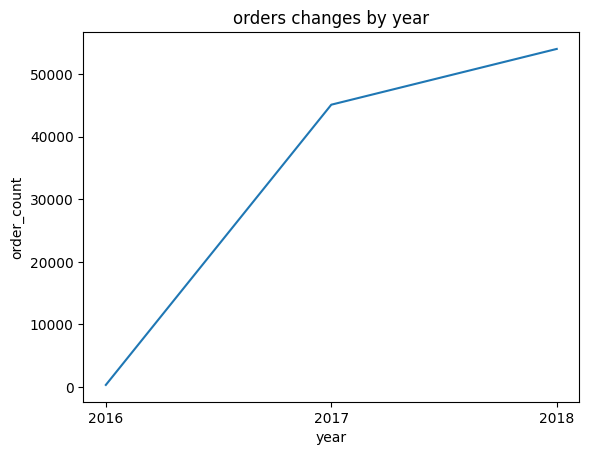

In [36]:
df_orders = pd.read_csv(data["orders"])
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"]) # convert object------> datetime
df_orders["year"] = df_orders["order_purchase_timestamp"].dt.year
orders_by_year = df_orders.groupby("year")["order_id"].count()
#orders_by_year.plot(kind="line")
sns.lineplot(x=orders_by_year.index,y=orders_by_year.values)
plt.xticks(ticks=[2016,2017,2018])
plt.title("orders changes by year")
plt.xlabel("year")
plt.ylabel("order_count")
plt.show()

In [41]:
years = orders_by_year.index.tolist()
counts = orders_by_year.tolist()
print(years,counts)

[2016, 2017, 2018] [329, 45101, 54011]


In [ ]:
45. How do orders change by month?
orders-->order_purchase_timestamp--->to_datetime-->extract month-->group by month-->count orders
I converted the order purchase timestamp to datetime, extracted the month, grouped the orders by month, and counted the orders for each month. 
    Then I visualized the monthly order trend using a Seaborn line chart and displayed the month names on the x-axis.


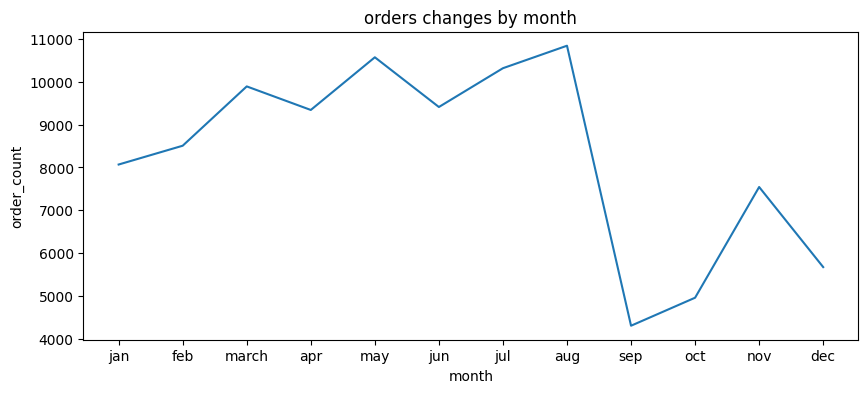

In [88]:
df_orders = pd.read_csv(data["orders"])
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"])

df_orders["month"] = df_orders["order_purchase_timestamp"].dt.month
# df_orders["month_name"] = df_orders["order_purchase_timestamp"].dt.month_name()

orders_by_month = df_orders.groupby("month")["order_id"].count().reset_index(name="order_count")

plt.figure(figsize=(10,4))
sns.lineplot(data = orders_by_month, x = "month",y = "order_count")
plt.xticks(ticks=[x for x in range(1,13)],labels=["jan","feb","march","apr","may","jun","jul","aug","sep","oct","nov","dec"])
# plt.xticks(range(1,13))
plt.title("orders changes by month")
plt.xlabel("month")
plt.ylabel("order_count")
plt.show()

In [ ]:
plt.xticks(ticks=[x for x in range(1,13)],labels=["jan","feb","march","apr","may","jun","jul","aug","sep","oct","nov","dec"])

In [ ]:
46. Which month has the highest number of orders?
To find which month had the highest number of orders, I grouped the orders by month and counted the `order_id` values. 
    Then I used `idxmax()` to find the month with the highest order count and `max()` to find the highest number of orders.
idxmax() is a Pandas function that returns the index/label where the maximum value occurs.

In [202]:
df_orders = pd.read_csv(data["orders"])
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"])
df_orders["month"] = df_orders["order_purchase_timestamp"].dt.month
orders_by_month = df_orders.groupby("month")["order_id"].count().sort_values(ascending=False)
print("max_order_month:",orders_by_month.idxmax())
print("max_order_count:",orders_by_month.max())

max_order_month: 8
max_order_count: 10843


In [151]:
orders_by_month

month
8     10843
5     10573
7     10318
3      9893
6      9412
4      9343
2      8508
1      8069
11     7544
12     5674
10     4959
9      4305
Name: order_id, dtype: int64

In [ ]:
47. Which month has the highest revenue?
Items → groupby(order_id),revenue → merge with Orders → extract month → monthly revenue → idxmax() → highest-revenue month → sns line plot
"idxmax() finds the index of the highest revenue, and .loc[] uses that index to retrieve the corresponding month."

highest_month_revenue: 5
max_revenue: 1502588.82
    month     revenue
0       1  1070343.23
1       2  1091481.73
2       3  1357557.74
3       4  1356574.98
4       5  1502588.82
5       6  1298162.91
6       7  1393538.70
7       8  1428658.01
8       9   624814.05
9      10   713727.09
10     11  1010271.37
11     12   743925.07


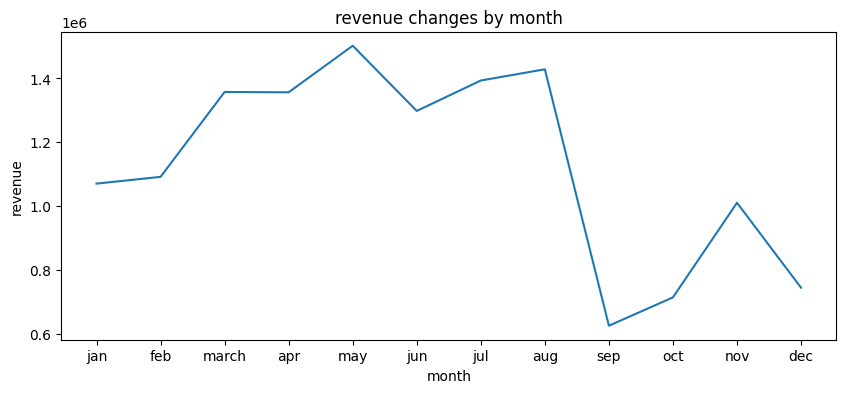

In [200]:
df_items = pd.read_csv(data["items"])
df_items_groupby = df_items.groupby("order_id")["price"].sum().sort_values(ascending=False)
df_merged = pd.merge(df_orders,df_items_groupby,on="order_id",how="inner")
df_merged["month"] = df_merged["order_purchase_timestamp"].dt.month
monthly_revenue = df_merged.groupby("month")["price"].sum().reset_index(name="revenue")

highest_month = monthly_revenue.loc[monthly_revenue["revenue"].idxmax(), "month"]
max_revenue = monthly_revenue["revenue"].max()

print("highest_month_revenue:", highest_month)
print("max_revenue:", max_revenue)
print(monthly_revenue)

plt.figure(figsize=(10,4))
sns.lineplot(data = monthly_revenue, x = "month",y = "revenue")
plt.xticks(ticks=[x for x in range(1,13)],labels=["jan","feb","march","apr","may","jun","jul","aug","sep","oct","nov","dec"])
plt.title("revenue changes by month")
plt.xlabel("month")
plt.ylabel("revenue")
plt.show()


In [195]:
monthly_revenue.loc[monthly_revenue["monthly_revenue"].idxmax(), "month"]


np.int32(5)

In [ ]:
48. Is there seasonal behavior?
Based on the available data, there appears to be some seasonal behavior. 
Revenue generally increased from January through May, decreased in June, and then improved again from June through August. 
Revenue dropped significantly in September, followed by some improvement in October and November, and then decreased again in December.
but this business insight is based on average monthly revenue across the available years of data.

    
However, this conclusion should be interpreted carefully because the dataset contains only a few months of data 
for 2016 and 2018, while 2017 contains a full year. Therefore, we cannot make a strong year-over-year seasonal conclusion for every month. 
Based on the available data, the highest revenue was in November 2017, at approximately $1,010,271. 
The lowest was December 2016, at approximately $10.90, but this very low value is likely influenced by the limited data available for 2016   

“The available data suggests a similar monthly pattern, 
but there is not enough complete multi-year data to confidently confirm strong seasonality.”


highest revenue year: 2017.0
highest revenue month: 11.0
highest revenue: 1010271.37
lowest revenue year: 2016.0
lowest revenue month: 12.0
lowest revenue: 10.9


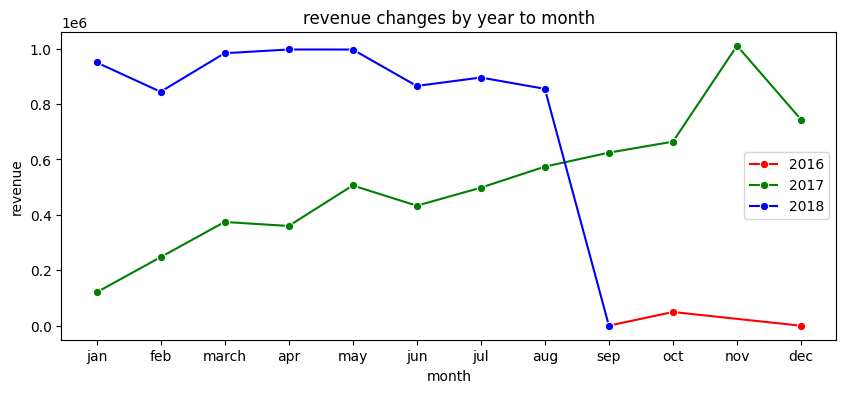

In [276]:
items_groupby = df_items.groupby("order_id")["price"].sum()
df_orders["year"] = df_orders["order_purchase_timestamp"].dt.year
df_orders["month"] = df_orders["order_purchase_timestamp"].dt.month

items_orders_merge = pd.merge(df_orders,items_groupby,on="order_id",how="inner")
year_month_revenue = items_orders_merge.groupby(["month","year"])["price"].sum().reset_index(name="revenue")

max_row = year_month_revenue.loc[
    year_month_revenue["revenue"].idxmax()]
print("highest revenue year:",max_row["year"])
print("highest revenue month:",max_row["month"])
print("highest revenue:",max_row["revenue"])

min_row = year_month_revenue.loc[
    year_month_revenue["revenue"].idxmin()]
print("lowest revenue year:",min_row["year"])
print("lowest revenue month:",min_row["month"])
print("lowest revenue:",min_row["revenue"])


plt.figure(figsize=(10,4))
sns.lineplot(data = year_month_revenue, x = "month",y = "revenue",hue="year",marker="o",palette={2016:"red",2017:"green",2018:"blue"})
plt.xticks(ticks=[x for x in range(1,13)],labels=["jan","feb","march","apr","may","jun","jul","aug","sep","oct","nov","dec"])
plt.title("revenue changes by year to month")
plt.xlabel("month")
plt.ylabel("revenue")
plt.legend()
plt.show()


In [ ]:
here we have in 2016 only few months of data,in 2017 we have full months of data but in 2018 also we have only few months of data.
    so according the data what we have is almost same seasonal behavior.but the highest revenue month is november 2017 revenue is 1010271 but 
    lowest revenue month is december 2016 revenue is 10.9